About Dataset

# 1. Data Loading & Exploration

## 1.1 Import Libraries

In [35]:
import pandas as pd
import numpy as np
import xgboost
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## 1.2 Load Dataset

In [36]:
df = pd.read_csv(
    r"C:\Users\NADA\Projects\Personal\AI\MachineLearning\Telco-Customer-Churn-ML\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


## 1.3 Basic inspection

In [37]:
print(df.shape)
print(df.columns.tolist())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
df.describe(include='all')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 1.5 Chercher les valeurs manquantes

In [40]:
df.isna().sum() #valeurs manquantes

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [41]:
df.duplicated().sum() #lignes dupliquées

np.int64(0)

In [42]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

# 2. Data cleaning

 ## 2.1 Convert TotalCharges to Numeric

In [118]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum() #détecter les valeurs qui ne peuvent pas être converties en nombres

np.int64(0)

In [119]:
df.loc[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
    ["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"] # les lignes où TotalCharges ne peut pas être converti en nombre avec certaines colonnes.
]

,tenure,MonthlyCharges,TotalCharges,Contract,Churn


## 2.3 Handle Invalid Values

In [120]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

## 2.4 Verify Data Cleaning

In [121]:
df["TotalCharges"].isna().sum() 

np.int64(0)

In [122]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

# 3. Exploratory Data Analysis (EDA)

## 3.1 Target Variable Distribution

In [48]:
df["Churn"].value_counts() 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [49]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 3.2 Categorical features vs Churn

In [50]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


--- gender ---
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

--- SeniorCitizen ---
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261

--- Partner ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

--- InternetService ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

--- OnlineSecurity ---
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes  

### Key Findings

L’analyse des variables catégorielles révèle plusieurs différences dans les taux de **churn** selon les groupes de clients.

- Le **type de contrat** présente une forte association avec le churn : les clients ayant un contrat **mensuel (Month-to-month)** présentent le taux de churn le plus élevé.
- Les clients utilisant le **paiement par chèque électronique (Electronic Check)** présentent un taux de churn nettement plus élevé que ceux utilisant les autres modes de paiement.
- Les clients utilisant le service Internet **Fiber Optic** présentent un taux de churn plus élevé que ceux utilisant le **DSL** ou n’ayant pas de service Internet.
- Les clients **sans Online Security ou Tech Support** ont tendance à présenter des taux de churn plus élevés.
- Les **personnes âgées (Senior Citizens)**, les clients **sans partenaire** et ceux **sans personnes à charge** présentent des taux de churn plus élevés.
- Le **genre** présente très peu de différence dans le taux de churn.

## 3.3 Numerical Features

In [51]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [52]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1679.525
Yes,10.0,79.650,703.550


##  Numerical Features Distribution

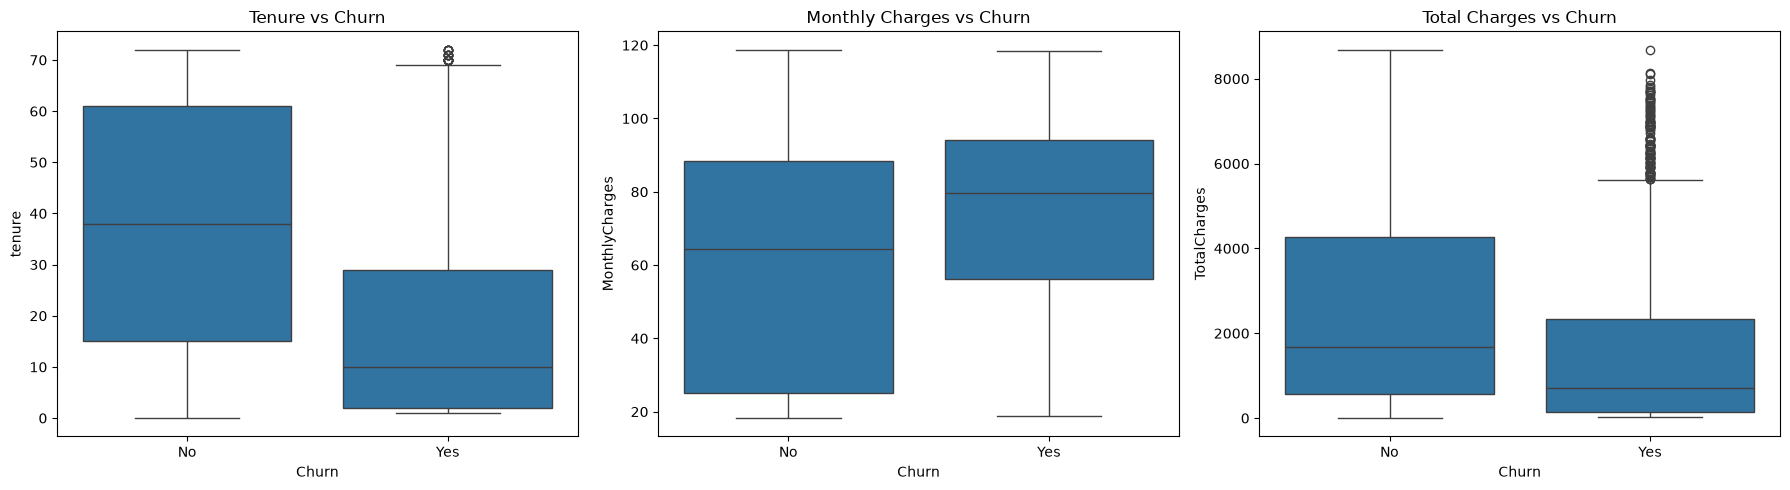

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

##  Correlation Analysis

- Values close to `1` → strong positive correlation
- Values close to `-1` → strong negative correlation
- Values close to `0` → weak or no linear correlation

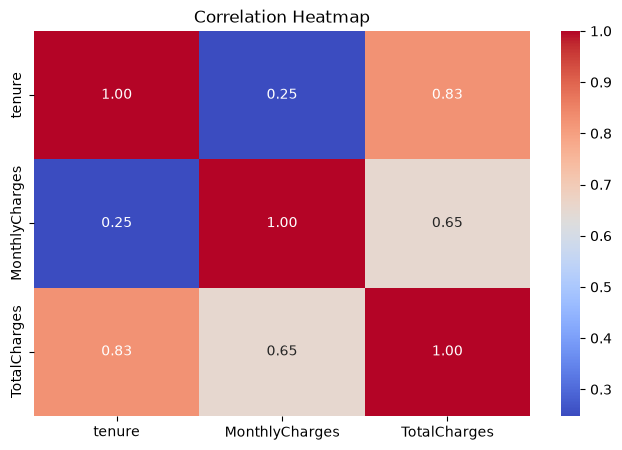

In [54]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The EDA revealed several patterns associated with customer churn:

- Month-to-month contracts have a substantially higher churn rate than one- and two-year contracts.
- Customers with lower tenure are more likely to churn.
- Customers with higher monthly charges tend to have higher churn rates.
- Customers without services such as OnlineSecurity and TechSupport show higher churn rates.
- Electronic check users have a particularly high churn rate.
- Gender shows little difference in churn rate.
- Tenure and TotalCharges are strongly related because TotalCharges accumulates over the customer's tenure.

# Feature Engineering

# Train / Test Split

In [55]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [56]:
y = y.map({"No": 0, "Yes": 1})

In [57]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [58]:
X = X.drop(columns=["customerID"])

In [69]:
from sklearn.model_selection import train_test_split

# 70% TRAIN / 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 15% VALIDATION / 15% TEST
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4930, 19)
Validation: (1056, 19)
Test: (1057, 19)


# Data Preprocessing

In [60]:
numeric_features = X_train.select_dtypes(include=["number"]).columns

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns

In [61]:
print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [62]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("catcat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Sélection du Modèle & Gestion du Déséquilibre (Class Imbalance)

1. **Sélection Initiale (Baseline) :** Test de 4 algorithmes différents avec leurs paramètres par défaut.


In [63]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
logistic_pipeline.fit(X_train, y_train)

tree_pipeline.fit(X_train, y_train)

rf_pipeline.fit(X_train, y_train)

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('catcat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [72]:
y_pred_logistic = logistic_pipeline.predict(X_val)
y_pred_tree = tree_pipeline.predict(X_val)
y_pred_rf = rf_pipeline.predict(X_val)
y_pred_xgb = xgb_pipeline.predict(X_val)

In [73]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, y_pred in models.items():

    print(name)

    print("Accuracy :", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred))
    print("Recall   :", recall_score(y_val, y_pred))
    print("F1 Score :", f1_score(y_val, y_pred))

    print()

Logistic Regression
Accuracy : 0.8058712121212122
Precision: 0.6459143968871596
Recall   : 0.5928571428571429
F1 Score : 0.6182495344506518

Decision Tree
Accuracy : 0.7178030303030303
Precision: 0.4689655172413793
Recall   : 0.4857142857142857
F1 Score : 0.47719298245614034

Random Forest
Accuracy : 0.7755681818181818
Precision: 0.5938864628820961
Recall   : 0.4857142857142857
F1 Score : 0.5343811394891945

XGBoost
Accuracy : 0.771780303030303
Precision: 0.5758754863813229
Recall   : 0.5285714285714286
F1 Score : 0.5512104283054003



2. **Filtrage :** Conservation des 2 meilleurs algorithmes.


## inbalnce class3. **Gestion du Déséquilibre :** Comparaison de deux approches (*Class Weight* vs *SMOTE*) combinées à l'optimisation du seuil de décision (*Threshold Tuning*).


In [67]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

Logistic Regression + Class Weight

In [74]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression

logistic_balanced = SkPipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

# Train uniquement
logistic_balanced.fit(X_train, y_train)

# Probabilités sur VALIDATION
y_proba_log_balanced = logistic_balanced.predict_proba(
    X_val
)[:, 1]

In [75]:
results_log_balanced = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_pred = (y_proba_log_balanced >= threshold).astype(int)

    results_log_balanced.append({
        "Model": "Logistic + Balanced",
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred)
    })

results_log_balanced = pd.DataFrame(results_log_balanced)

results_log_balanced

,Model,Threshold,Precision,Recall,F1
0,Logistic + Balanced,0.20,0.385387,0.960714,0.550102
1,Logistic + Balanced,0.25,0.401216,0.942857,0.562900
2,Logistic + Balanced,0.30,0.424390,0.932143,0.583240
3,Logistic + Balanced,0.35,0.444637,0.917857,0.599068
4,Logistic + Balanced,0.40,0.467925,0.885714,0.612346
5,Logistic + Balanced,0.45,0.483806,0.853571,0.617571
6,Logistic + Balanced,0.50,0.505543,0.814286,0.623803
7,Logistic + Balanced,0.55,0.522459,0.789286,0.628734
8,Logistic + Balanced,0.60,0.527919,0.742857,0.617211
9,Logistic + Balanced,0.65,0.556497,0.703571,0.621451


XGBoost + Class Weight

In [76]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline as SkPipeline

# Calcul du poids de la classe minoritaire
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight)

# XGBoost + Class Weight
xgb_balanced = SkPipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Entraînement uniquement sur TRAIN
xgb_balanced.fit(X_train, y_train)

# Probabilités sur VALIDATION
y_proba_xgb_balanced = (
    xgb_balanced.predict_proba(X_val)[:, 1]
)

scale_pos_weight: 2.7691131498470947


In [77]:
results_xgb_balanced = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_pred = (y_proba_xgb_balanced >= threshold).astype(int)

    results_xgb_balanced.append({
        "Model": "XGBoost + Balanced",
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred)
    })

results_xgb_balanced = pd.DataFrame(results_xgb_balanced)

results_xgb_balanced

,Model,Threshold,Precision,Recall,F1
0,XGBoost + Balanced,0.20,0.451613,0.850000,0.589839
1,XGBoost + Balanced,0.25,0.472112,0.846429,0.606138
2,XGBoost + Balanced,0.30,0.494577,0.814286,0.615385
3,XGBoost + Balanced,0.35,0.500000,0.767857,0.605634
4,XGBoost + Balanced,0.40,0.505051,0.714286,0.591716
5,XGBoost + Balanced,0.45,0.516304,0.678571,0.586420
6,XGBoost + Balanced,0.50,0.527536,0.650000,0.582400
7,XGBoost + Balanced,0.55,0.543750,0.621429,0.580000
8,XGBoost + Balanced,0.60,0.551495,0.592857,0.571429
9,XGBoost + Balanced,0.65,0.551971,0.550000,0.550984


Logistic Regression + SMOTE

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# Logistic Regression + SMOTE
logistic_smote = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

# SMOTE + entraînement uniquement sur TRAIN
logistic_smote.fit(X_train, y_train)

# Probabilités sur VALIDATION
y_proba_log_smote = logistic_smote.predict_proba(
    X_val
)[:, 1]

In [83]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results_log_smote = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_pred = (
        y_proba_log_smote >= threshold
    ).astype(int)

    results_log_smote.append({
        "Model": "Logistic + SMOTE",
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    })

results_log_smote = pd.DataFrame(
    results_log_smote
)

results_log_smote

,Model,Threshold,Precision,Recall,F1
0,Logistic + SMOTE,0.20,0.392128,0.960714,0.556936
1,Logistic + SMOTE,0.25,0.409375,0.935714,0.569565
2,Logistic + SMOTE,0.30,0.434564,0.925000,0.591324
3,Logistic + SMOTE,0.35,0.446809,0.900000,0.597156
4,Logistic + SMOTE,0.40,0.473282,0.885714,0.616915
5,Logistic + SMOTE,0.45,0.492600,0.832143,0.618858
6,Logistic + SMOTE,0.50,0.509934,0.825000,0.630286
7,Logistic + SMOTE,0.55,0.525547,0.771429,0.625181
8,Logistic + SMOTE,0.60,0.540470,0.739286,0.624434
9,Logistic + SMOTE,0.65,0.554598,0.689286,0.614650


XGBoost + SMOTE

In [84]:
xgb_smote = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train uniquement
xgb_smote.fit(X_train, y_train)

# Validation
y_proba_xgb_smote = (
    xgb_smote.predict_proba(X_val)[:, 1]
)

In [85]:
results_xgb_smote = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_pred = (
        y_proba_xgb_smote >= threshold
    ).astype(int)

    results_xgb_smote.append({
        "Model": "XGBoost + SMOTE",
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred)
    })

results_xgb_smote = pd.DataFrame(
    results_xgb_smote
)

results_xgb_smote

,Model,Threshold,Precision,Recall,F1
0,XGBoost + SMOTE,0.20,0.483940,0.807143,0.605087
1,XGBoost + SMOTE,0.25,0.503497,0.771429,0.609309
2,XGBoost + SMOTE,0.30,0.521519,0.735714,0.610370
3,XGBoost + SMOTE,0.35,0.539726,0.703571,0.610853
4,XGBoost + SMOTE,0.40,0.543284,0.650000,0.591870
5,XGBoost + SMOTE,0.45,0.565916,0.628571,0.595601
6,XGBoost + SMOTE,0.50,0.591398,0.589286,0.590340
7,XGBoost + SMOTE,0.55,0.597701,0.557143,0.576710
8,XGBoost + SMOTE,0.60,0.614035,0.500000,0.551181
9,XGBoost + SMOTE,0.65,0.601942,0.442857,0.510288


In [86]:
# Combiner les résultats des 4 approches
all_results = pd.concat([
    results_log_balanced,
    results_log_smote,
    results_xgb_balanced,
    results_xgb_smote
], ignore_index=True)

# Garder uniquement les résultats avec Precision > 0.38
best_results = all_results[
    all_results["Precision"] > 0.38
].sort_values(
    by=["Recall", "F1"],
    ascending=False
)

# Afficher les 10 meilleures combinaisons
best_results.head(10)

,Model,Threshold,Precision,Recall,F1
11,Logistic + SMOTE,0.20,0.392128,0.960714,0.556936
0,Logistic + Balanced,0.20,0.385387,0.960714,0.550102
1,Logistic + Balanced,0.25,0.401216,0.942857,0.562900
12,Logistic + SMOTE,0.25,0.409375,0.935714,0.569565
2,Logistic + Balanced,0.30,0.424390,0.932143,0.583240
13,Logistic + SMOTE,0.30,0.434564,0.925000,0.591324
3,Logistic + Balanced,0.35,0.444637,0.917857,0.599068
14,Logistic + SMOTE,0.35,0.446809,0.900000,0.597156
15,Logistic + SMOTE,0.40,0.473282,0.885714,0.616915
4,Logistic + Balanced,0.40,0.467925,0.885714,0.612346


4. **Optimisation Finale (Tuning) :** Recherche des hyperparamètres optimaux sur les configurations gagnantes.


Imports

In [ ]:
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
def recall_with_precision_constraint(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    if precision < 0.38:
        return 0

    return recall
def recall_with_precision_constraint(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    if precision < 0.38:
        return 0

    return recall
custom_scorer = make_scorer(recall_with_precision_constraint)

1. Optuna — Logistic Regression + Class Weight

In [87]:
import optuna
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


def objective_logistic_balanced(trial):

    C = trial.suggest_float(
        "C",
        0.001,
        10,
        log=True
    )

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs"]
    )

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(
            C=C,
            solver=solver,
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    return scores.mean()


study_logistic_balanced = optuna.create_study(
    direction="maximize"
)

study_logistic_balanced.optimize(
    objective_logistic_balanced,
    n_trials=30
)

print("Best parameters:")
print(study_logistic_balanced.best_params)

print("Best CV Recall:")
print(study_logistic_balanced.best_value)

[I 2026-08-22 22:34:43,052] A new study created in memory with name: no-name-dd011ebc-65f8-4ee6-8ee3-ec7044bb344e
[I 2026-08-22 22:34:45,763] Trial 0 finished with value: 0.7905208973121581 and parameters: {'C': 0.014912227019104288, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7905208973121581.
[I 2026-08-22 22:34:47,772] Trial 1 finished with value: 0.7989383171009915 and parameters: {'C': 0.1718124347066295, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.7989383171009915.
[I 2026-08-22 22:34:49,306] Trial 2 finished with value: 0.8012283934368692 and parameters: {'C': 0.3419415748462981, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.8012283934368692.
[I 2026-08-22 22:34:49,412] Trial 3 finished with value: 0.8012283934368692 and parameters: {'C': 0.3943312210341176, 'solver': 'liblinear'}. Best is trial 2 with value: 0.8012283934368692.
[I 2026-08-22 22:34:49,518] Trial 4 finished with value: 0.7997046006258957 and parameters: {'C': 3.7521838427359673, 'solver': 'libline

Best parameters:
{'C': 0.4688091877585022, 'solver': 'liblinear'}
Best CV Recall:
0.8019946769617736


In [88]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression

best_logistic_balanced = SkPipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        **study_logistic_balanced.best_params,
        class_weight="balanced",
        max_iter=1000
    ))
])

# Entraînement uniquement sur TRAIN
best_logistic_balanced.fit(
    X_train,
    y_train
)

# Probabilités sur VALIDATION
y_val_proba_log_balanced = (
    best_logistic_balanced.predict_proba(X_val)[:, 1]
)

print("Best Logistic + Balanced model trained.")

Best Logistic + Balanced model trained.


In [90]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results_log_balanced_optuna = []

for threshold in np.arange(0.10, 0.71, 0.01):

    y_pred = (
        y_val_proba_log_balanced >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    if precision >= 0.38:

        results_log_balanced_optuna.append({
            "Model": "Logistic + Balanced + Optuna",
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

results_log_balanced_optuna = pd.DataFrame(
    results_log_balanced_optuna
)

results_log_balanced_optuna = (
    results_log_balanced_optuna
    .sort_values(
        by=["Recall", "F1"],
        ascending=False
    )
)

results_log_balanced_optuna.head(12)

,Model,Threshold,Precision,Recall,F1
0,Logistic + Balanced + Optuna,0.20,0.385164,0.964286,0.550459
2,Logistic + Balanced + Optuna,0.22,0.390421,0.960714,0.555212
1,Logistic + Balanced + Optuna,0.21,0.387608,0.960714,0.552361
3,Logistic + Balanced + Optuna,0.23,0.395864,0.957143,0.560084
4,Logistic + Balanced + Optuna,0.24,0.398507,0.953571,0.562105
5,Logistic + Balanced + Optuna,0.25,0.401515,0.946429,0.563830
6,Logistic + Balanced + Optuna,0.26,0.405530,0.942857,0.567132
7,Logistic + Balanced + Optuna,0.27,0.410938,0.939286,0.571739
9,Logistic + Balanced + Optuna,0.29,0.420546,0.935714,0.580288
8,Logistic + Balanced + Optuna,0.28,0.414557,0.935714,0.574561


Logistic Regression + SMOTE

In [91]:
import optuna

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


def objective_logistic_smote(trial):

    C = trial.suggest_float(
        "C",
        0.001,
        10,
        log=True
    )

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs"]
    )

    model = ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            C=C,
            solver=solver,
            max_iter=1000
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    return scores.mean()


study_logistic_smote = optuna.create_study(
    direction="maximize"
)

study_logistic_smote.optimize(
    objective_logistic_smote,
    n_trials=30
)

print("Best parameters:")
print(study_logistic_smote.best_params)

print("Best CV Recall:")
print(study_logistic_smote.best_value)

[I 2026-08-22 22:37:59,779] A new study created in memory with name: no-name-47286dc5-2621-434e-b5d0-d20228fb2b17
[I 2026-08-22 22:38:00,270] Trial 0 finished with value: 0.7859319704015676 and parameters: {'C': 0.026837120416870405, 'solver': 'liblinear'}. Best is trial 0 with value: 0.7859319704015676.
[I 2026-08-22 22:38:00,736] Trial 1 finished with value: 0.7943406159515662 and parameters: {'C': 3.0374373795113527, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.7943406159515662.
[I 2026-08-22 22:38:01,033] Trial 2 finished with value: 0.7805855342049077 and parameters: {'C': 0.004946344546839993, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.7943406159515662.
[I 2026-08-22 22:38:01,123] Trial 3 finished with value: 0.7821093270158814 and parameters: {'C': 0.015841302717572652, 'solver': 'liblinear'}. Best is trial 1 with value: 0.7943406159515662.
[I 2026-08-22 22:38:01,222] Trial 4 finished with value: 0.7935714076803837 and parameters: {'C': 0.34138252366935534, 'solver':

Best parameters:
{'C': 0.7230202775703984, 'solver': 'liblinear'}
Best CV Recall:
0.7958702582550965


In [93]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

best_logistic_smote = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        **study_logistic_smote.best_params,
        max_iter=1000
    ))
])

# Entraînement uniquement sur TRAIN
best_logistic_smote.fit(
    X_train,
    y_train
)

# Probabilités sur VALIDATION
y_val_proba_log_smote = (
    best_logistic_smote.predict_proba(X_val)[:, 1]
)

print("Best Logistic + SMOTE model trained.")
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results_log_smote_optuna = []

for threshold in np.arange(0.10, 0.71, 0.01):

    y_pred = (
        y_val_proba_log_smote >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    if precision >= 0.38:

        results_log_smote_optuna.append({
            "Model": "Logistic + SMOTE + Optuna",
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

results_log_smote_optuna = pd.DataFrame(
    results_log_smote_optuna
)

results_log_smote_optuna = (
    results_log_smote_optuna
    .sort_values(
        by=["Recall", "F1"],
        ascending=False
    )
)

results_log_smote_optuna.head(10)

Best Logistic + SMOTE model trained.


,Model,Threshold,Precision,Recall,F1
0,Logistic + SMOTE + Optuna,0.17,0.380618,0.967857,0.546371
1,Logistic + SMOTE + Optuna,0.18,0.385164,0.964286,0.550459
3,Logistic + SMOTE + Optuna,0.20,0.392128,0.960714,0.556936
2,Logistic + SMOTE + Optuna,0.19,0.388167,0.960714,0.552929
4,Logistic + SMOTE + Optuna,0.21,0.394118,0.957143,0.558333
5,Logistic + SMOTE + Optuna,0.22,0.397914,0.953571,0.561514
6,Logistic + SMOTE + Optuna,0.23,0.402421,0.950000,0.565356
7,Logistic + SMOTE + Optuna,0.24,0.405864,0.939286,0.566810
8,Logistic + SMOTE + Optuna,0.25,0.408736,0.935714,0.568947
10,Logistic + SMOTE + Optuna,0.27,0.420290,0.932143,0.579356


comparer les deux

In [96]:
# Combiner les résultats des deux modèles
all_logistic_results = pd.concat([
    results_log_balanced_optuna,
    results_log_smote_optuna
], ignore_index=True)

# Garder uniquement les résultats avec Precision >= 0.38
best_logistic_results = all_logistic_results[
    all_logistic_results["Precision"] >= 0.42
].sort_values(
    by=["Recall", "F1"],
    ascending=False
)

# Afficher les 10 meilleurs
best_logistic_results.head(10)

,Model,Threshold,Precision,Recall,F1
8,Logistic + Balanced + Optuna,0.29,0.420546,0.935714,0.580288
10,Logistic + Balanced + Optuna,0.30,0.423015,0.932143,0.581940
60,Logistic + SMOTE + Optuna,0.27,0.420290,0.932143,0.579356
11,Logistic + Balanced + Optuna,0.32,0.435511,0.928571,0.592930
12,Logistic + Balanced + Optuna,0.31,0.429752,0.928571,0.587571
62,Logistic + SMOTE + Optuna,0.28,0.426230,0.928571,0.584270
13,Logistic + Balanced + Optuna,0.33,0.438983,0.925000,0.595402
63,Logistic + SMOTE + Optuna,0.30,0.434564,0.925000,0.591324
64,Logistic + SMOTE + Optuna,0.29,0.430233,0.925000,0.587302
14,Logistic + Balanced + Optuna,0.34,0.442539,0.921429,0.597914


XGBOOST OPTUNA

XGBoost + Class Weight (scale_pos_weight) + Optuna

In [97]:
import optuna

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


def objective_xgb_balanced(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 6
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "gamma": trial.suggest_float(
            "gamma", 0, 5
        )
    }

    # Calcul du poids des classes sur TRAIN uniquement
    scale_pos_weight = (
        (y_train == 0).sum()
        / (y_train == 1).sum()
    )

    model = Pipeline([
        ("preprocessing", preprocessor),

        ("model", XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    return scores.mean()


study_xgb_balanced = optuna.create_study(
    direction="maximize"
)

study_xgb_balanced.optimize(
    objective_xgb_balanced,
    n_trials=30
)

print("Best parameters:")
print(study_xgb_balanced.best_params)

print("Best CV Recall:")
print(study_xgb_balanced.best_value)
from sklearn.pipeline import Pipeline as SkPipeline
from xgboost import XGBClassifier

# Calcul du poids des classes sur TRAIN
scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

# Meilleur XGBoost + Class Weight
best_xgb_balanced = SkPipeline([
    (
        "preprocessing",
        preprocessor
    ),

    (
        "model",
        XGBClassifier(
            **study_xgb_balanced.best_params,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

# Entraînement uniquement sur TRAIN
best_xgb_balanced.fit(
    X_train,
    y_train
)

# Probabilités sur VALIDATION
y_val_proba_xgb_balanced = (
    best_xgb_balanced.predict_proba(X_val)[:, 1]
)

print("Best XGBoost + Balanced model trained.")

[I 2026-08-22 22:44:00,252] A new study created in memory with name: no-name-4a8019f1-317a-48de-b09f-a01fb0759ca0
[I 2026-08-22 22:44:03,263] Trial 0 finished with value: 0.7928197478868709 and parameters: {'n_estimators': 212, 'max_depth': 2, 'learning_rate': 0.12211657995774268, 'subsample': 0.8293514220861723, 'colsample_bytree': 0.7928502090483115, 'min_child_weight': 10, 'gamma': 1.099503576393397}. Best is trial 0 with value: 0.7928197478868709.
[I 2026-08-22 22:44:07,128] Trial 1 finished with value: 0.8065777543798076 and parameters: {'n_estimators': 233, 'max_depth': 2, 'learning_rate': 0.0853291219592419, 'subsample': 0.8176292797136058, 'colsample_bytree': 0.9343827758264502, 'min_child_weight': 9, 'gamma': 3.7151865445925134}. Best is trial 1 with value: 0.8065777543798076.
[I 2026-08-22 22:44:13,335] Trial 2 finished with value: 0.7890146529788541 and parameters: {'n_estimators': 193, 'max_depth': 3, 'learning_rate': 0.06181421926858198, 'subsample': 0.8803896878398401, 'c

Best parameters:
{'n_estimators': 342, 'max_depth': 2, 'learning_rate': 0.014083364171391548, 'subsample': 0.9574633940932642, 'colsample_bytree': 0.8777600161134271, 'min_child_weight': 7, 'gamma': 4.914070016595697}
Best CV Recall:
0.8172852505045187
Best XGBoost + Balanced model trained.


In [98]:


from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results_xgb_balanced_optuna = []

for threshold in np.arange(0.10, 0.71, 0.01):

    y_pred = (
        y_val_proba_xgb_balanced >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    if precision >= 0.38:

        results_xgb_balanced_optuna.append({
            "Model": "XGBoost + Balanced + Optuna",
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

results_xgb_balanced_optuna = pd.DataFrame(
    results_xgb_balanced_optuna
)

results_xgb_balanced_optuna = (
    results_xgb_balanced_optuna
    .sort_values(
        by=["Recall", "F1"],
        ascending=False
    )
)

results_xgb_balanced_optuna.head(10)

,Model,Threshold,Precision,Recall,F1
0,XGBoost + Balanced + Optuna,0.23,0.385269,0.971429,0.551724
2,XGBoost + Balanced + Optuna,0.25,0.393586,0.964286,0.559006
1,XGBoost + Balanced + Optuna,0.24,0.389049,0.964286,0.554415
5,XGBoost + Balanced + Optuna,0.28,0.411315,0.960714,0.576017
4,XGBoost + Balanced + Optuna,0.27,0.405732,0.960714,0.570520
3,XGBoost + Balanced + Optuna,0.26,0.400298,0.960714,0.565126
6,XGBoost + Balanced + Optuna,0.29,0.418097,0.957143,0.581976
7,XGBoost + Balanced + Optuna,0.30,0.423138,0.953571,0.586169
8,XGBoost + Balanced + Optuna,0.31,0.427419,0.946429,0.588889
9,XGBoost + Balanced + Optuna,0.32,0.428339,0.939286,0.588367


XGBoost + SMOTE + Optuna

In [99]:
import optuna

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score


def objective_xgb_smote(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 6
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "gamma": trial.suggest_float(
            "gamma", 0, 5
        )
    }

    model = ImbPipeline([
        (
            "preprocessing",
            preprocessor
        ),

        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),

        (
            "model",
            XGBClassifier(
                **params,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    return scores.mean()


study_xgb_smote = optuna.create_study(
    direction="maximize"
)

study_xgb_smote.optimize(
    objective_xgb_smote,
    n_trials=30
)

print("Best parameters:")
print(study_xgb_smote.best_params)

print("Best CV Recall:")
print(study_xgb_smote.best_value)

[I 2026-08-22 22:45:49,165] A new study created in memory with name: no-name-ee2170da-ae69-4f25-b9ab-de7c0fe87cd5
[I 2026-08-22 22:45:50,158] Trial 0 finished with value: 0.6246205141703957 and parameters: {'n_estimators': 434, 'max_depth': 5, 'learning_rate': 0.1032104117105643, 'subsample': 0.7426712480510079, 'colsample_bytree': 0.7240012153359796, 'min_child_weight': 7, 'gamma': 2.2706353122403113}. Best is trial 0 with value: 0.6246205141703957.
[I 2026-08-22 22:45:51,109] Trial 1 finished with value: 0.6200579099763096 and parameters: {'n_estimators': 281, 'max_depth': 6, 'learning_rate': 0.09300744639694189, 'subsample': 0.9534879044543207, 'colsample_bytree': 0.9128569364546782, 'min_child_weight': 8, 'gamma': 0.8625565922211254}. Best is trial 0 with value: 0.6246205141703957.
[I 2026-08-22 22:45:52,144] Trial 2 finished with value: 0.6980082477845047 and parameters: {'n_estimators': 395, 'max_depth': 4, 'learning_rate': 0.011167789146072842, 'subsample': 0.8163761031225221, '

Best parameters:
{'n_estimators': 250, 'max_depth': 2, 'learning_rate': 0.010070362444120582, 'subsample': 0.776498678397098, 'colsample_bytree': 0.8747270120744168, 'min_child_weight': 10, 'gamma': 1.0450114017963732}
Best CV Recall:
0.7775174753590125


In [100]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


best_xgb_smote = ImbPipeline([
    (
        "preprocessing",
        preprocessor
    ),

    (
        "smote",
        SMOTE(random_state=42)
    ),

    (
        "model",
        XGBClassifier(
            **study_xgb_smote.best_params,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])


# Entraînement uniquement sur TRAIN
best_xgb_smote.fit(
    X_train,
    y_train
)


# Probabilités sur VALIDATION
y_val_proba_xgb_smote = (
    best_xgb_smote.predict_proba(X_val)[:, 1]
)

print("Best XGBoost + SMOTE model trained.")
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


results_xgb_smote_optuna = []


for threshold in np.arange(0.10, 0.71, 0.01):

    y_pred = (
        y_val_proba_xgb_smote >= threshold
    ).astype(int)


    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )


    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )


    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )


    # Contrainte métier
    if precision >= 0.38:

        results_xgb_smote_optuna.append({
            "Model": "XGBoost + SMOTE + Optuna",
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })


results_xgb_smote_optuna = pd.DataFrame(
    results_xgb_smote_optuna
)


results_xgb_smote_optuna = (
    results_xgb_smote_optuna
    .sort_values(
        by=["Recall", "F1"],
        ascending=False
    )
)


results_xgb_smote_optuna.head(10)

Best XGBoost + SMOTE model trained.


,Model,Threshold,Precision,Recall,F1
0,XGBoost + SMOTE + Optuna,0.24,0.386139,0.975000,0.553191
1,XGBoost + SMOTE + Optuna,0.25,0.388571,0.971429,0.555102
2,XGBoost + SMOTE + Optuna,0.26,0.397341,0.960714,0.562173
3,XGBoost + SMOTE + Optuna,0.27,0.405159,0.953571,0.568690
4,XGBoost + SMOTE + Optuna,0.28,0.406442,0.946429,0.568670
5,XGBoost + SMOTE + Optuna,0.29,0.411303,0.935714,0.571429
6,XGBoost + SMOTE + Optuna,0.30,0.417335,0.928571,0.575858
7,XGBoost + SMOTE + Optuna,0.31,0.418417,0.925000,0.576196
8,XGBoost + SMOTE + Optuna,0.32,0.423645,0.921429,0.580427
9,XGBoost + SMOTE + Optuna,0.33,0.426667,0.914286,0.581818


on compare les 4

In [104]:
# Combiner les résultats des 4 modèles

all_results_optuna = pd.concat([
    results_log_balanced_optuna,
    results_log_smote_optuna,
    results_xgb_balanced_optuna,
    results_xgb_smote_optuna
], ignore_index=True)


# Garder uniquement les configurations
# avec Precision >= 0.38

best_results_optuna = all_results_optuna[
    all_results_optuna["Precision"] >= 0.42
].sort_values(
    by=["Recall", "F1"],
    ascending=False
)


# Afficher les 10 meilleures configurations

best_results_optuna.head(10)

,Model,Threshold,Precision,Recall,F1
112,XGBoost + Balanced + Optuna,0.30,0.423138,0.953571,0.586169
113,XGBoost + Balanced + Optuna,0.31,0.427419,0.946429,0.588889
114,XGBoost + Balanced + Optuna,0.32,0.428339,0.939286,0.588367
115,XGBoost + Balanced + Optuna,0.33,0.433058,0.935714,0.592090
8,Logistic + Balanced + Optuna,0.29,0.420546,0.935714,0.580288
10,Logistic + Balanced + Optuna,0.30,0.423015,0.932143,0.581940
60,Logistic + SMOTE + Optuna,0.27,0.420290,0.932143,0.579356
11,Logistic + Balanced + Optuna,0.32,0.435511,0.928571,0.592930
12,Logistic + Balanced + Optuna,0.31,0.429752,0.928571,0.587571
62,Logistic + SMOTE + Optuna,0.28,0.426230,0.928571,0.584270


In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# FINAL TEST — XGBoost + Balanced + Optuna
# ==========================================

final_threshold = 0.30

# Probabilities on TEST
y_test_proba = (
    best_xgb_balanced.predict_proba(X_test)[:, 1]
)

# Apply the threshold selected on VALIDATION
y_test_pred = (
    y_test_proba >= final_threshold
).astype(int)


# ==========================================
# Metrics
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)


print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print("Model     : XGBoost + Balanced + Optuna")
print(f"Threshold : {final_threshold:.2f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

FINAL TEST RESULTS
Model     : XGBoost + Balanced + Optuna
Threshold : 0.30
Accuracy  : 0.6367
Precision : 0.4163
Recall    : 0.9110
F1 Score  : 0.5714


In [106]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0, 5
        ),

        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", XGBClassifier(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-08-23 01:04:27,864] A new study created in memory with name: no-name-b7c8157d-b152-4a86-98bd-288b2ea2bef0
[I 2026-08-23 01:04:31,918] Trial 0 finished with value: 0.5183761808663098 and parameters: {'n_estimators': 486, 'max_depth': 4, 'learning_rate': 0.05122233483353478, 'subsample': 0.7013425962106885, 'colsample_bytree': 0.7020432332706246, 'min_child_weight': 9, 'gamma': 1.8391980132799617}. Best is trial 0 with value: 0.5183761808663098.
[I 2026-08-23 01:04:35,002] Trial 1 finished with value: 0.53286829867509 and parameters: {'n_estimators': 144, 'max_depth': 4, 'learning_rate': 0.17517816601510972, 'subsample': 0.8180708745697474, 'colsample_bytree': 0.7761815475657845, 'min_child_weight': 10, 'gamma': 2.8992039817779642}. Best is trial 1 with value: 0.53286829867509.
[I 2026-08-23 01:04:38,541] Trial 2 finished with value: 0.5374689245707935 and parameters: {'n_estimators': 301, 'max_depth': 4, 'learning_rate': 0.14332467458560075, 'subsample': 0.8302137980907547, 'col

In [107]:
print("Best parameters:")
print(study.best_params)

print("\nBest CV Recall:")
print(study.best_value)

Best parameters:
{'n_estimators': 272, 'max_depth': 4, 'learning_rate': 0.09906092797149485, 'subsample': 0.8849215437417047, 'colsample_bytree': 0.8431151645921264, 'min_child_weight': 10, 'gamma': 2.6159231580774795}

Best CV Recall:
0.5405428329092452


In [ ]:
best_xgb_optuna = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        **study.best_params,
        random_state=42,
        eval_metric="logloss"
    ))
])
best_xgb_optuna.fit(X_train, y_train)
y_val_proba_optuna = best_xgb_optuna.predict_proba(X_val)[:, 1]
results_optuna = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_val_pred = (y_val_proba_optuna >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    if precision >= 0.38:

        results_optuna.append({
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

results_optuna = pd.DataFrame(results_optuna)

results_optuna.sort_values(
    by=["Recall", "F1"],
    ascending=False
)

,Threshold,Precision,Recall,F1
0,0.20,0.508443,0.906355,0.651442
1,0.25,0.544662,0.836120,0.659631
2,0.30,0.575243,0.792642,0.666667
3,0.35,0.629738,0.722408,0.672897
4,0.40,0.665574,0.678930,0.672185
5,0.45,0.705882,0.642140,0.672504
6,0.50,0.737288,0.581940,0.650467
7,0.55,0.752525,0.498328,0.599598
8,0.60,0.779874,0.414716,0.541485
9,0.65,0.804878,0.331104,0.469194


trouvons un meilleur recall 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results_fine = []

for threshold in np.arange(0.10, 0.51, 0.01):

    y_val_pred = (y_val_proba_optuna >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    results_fine.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

results_fine = pd.DataFrame(results_fine)
results_filtered = results_fine[
    results_fine["Precision"] >= 0.40
].sort_values(
    by=["Recall", "F1"],
    ascending=False
)

results_filtered.head(10)

,Threshold,Precision,Recall,F1
0,0.10,0.411175,0.959866,0.575727
1,0.11,0.423704,0.956522,0.587269
3,0.13,0.441315,0.943144,0.601279
2,0.12,0.430534,0.943144,0.591195
4,0.14,0.453074,0.936455,0.610687
5,0.15,0.460396,0.933110,0.616575
7,0.17,0.479167,0.923077,0.630857
6,0.16,0.467005,0.923077,0.620225
8,0.18,0.488414,0.916388,0.637209
9,0.19,0.496364,0.913043,0.643110


In [ ]:
y_test_proba_logistic = logistic_balanced.predict_proba(X_test)[:, 1]

y_test_pred_logistic = (y_test_proba_logistic >= 0.20).astype(int)

print("Logistic + Balanced - Threshold 0.20")
print("Accuracy :", accuracy_score(y_test, y_test_pred_logistic))
print("Precision:", precision_score(y_test, y_test_pred_logistic))
print("Recall   :", recall_score(y_test, y_test_pred_logistic))
print("F1 Score :", f1_score(y_test, y_test_pred_logistic))

Logistic + Balanced - Threshold 0.20
Accuracy : 0.5883605393896381
Precision: 0.38876889848812096
Recall   : 0.9625668449197861
F1 Score : 0.5538461538461539


In [ ]:
y_test_proba_optuna = best_xgb_optuna.predict_proba(X_test)[:, 1]

y_test_pred_optuna = (y_test_proba_optuna >= 0.17).astype(int)

print("XGBoost + Optuna - Threshold 0.17")
print("Accuracy :", accuracy_score(y_test, y_test_pred_optuna))
print("Precision:", precision_score(y_test, y_test_pred_optuna))
print("Recall   :", recall_score(y_test, y_test_pred_optuna))
print("F1 Score :", f1_score(y_test, y_test_pred_optuna))

XGBoost + Optuna - Threshold 0.17
Accuracy : 0.6976579134137686
Precision: 0.4630681818181818
Recall   : 0.8716577540106952
F1 Score : 0.6048237476808905


In [128]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

best_xgb_optuna = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        **study.best_params,
        random_state=42,
        eval_metric="logloss"
    ))
])

best_xgb_optuna.fit(
    X_train,
    y_train
)
y_val_proba = best_xgb_optuna.predict_proba(
    X_val
)[:, 1]
results_xgb_optuna = []

for threshold in np.arange(0.10, 0.51, 0.01):

    y_val_pred = (
        y_val_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val, y_val_pred, zero_division=0
    )

    recall = recall_score(
        y_val, y_val_pred, zero_division=0
    )

    f1 = f1_score(
        y_val, y_val_pred, zero_division=0
    )

    accuracy = accuracy_score(
        y_val, y_val_pred
    )

    if precision >= 0.42:

        results_xgb_optuna.append({
            "Model": "XGBoost + Optuna",
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

results_xgb_optuna = pd.DataFrame(
    results_xgb_optuna
)

results_xgb_optuna.sort_values(
    by=["Recall", "F1"],
    ascending=False
).head(10)

,Model,Threshold,Accuracy,Precision,Recall,F1
0,XGBoost + Optuna,0.12,0.645833,0.424437,0.942857,0.585366
1,XGBoost + Optuna,0.13,0.658144,0.433058,0.935714,0.592090
3,XGBoost + Optuna,0.15,0.681818,0.451557,0.932143,0.608392
2,XGBoost + Optuna,0.14,0.672348,0.443878,0.932143,0.601382
4,XGBoost + Optuna,0.16,0.688447,0.456172,0.910714,0.607867
6,XGBoost + Optuna,0.18,0.710227,0.475191,0.889286,0.619403
5,XGBoost + Optuna,0.17,0.699811,0.465421,0.889286,0.611043
7,XGBoost + Optuna,0.19,0.712121,0.476744,0.878571,0.618090
8,XGBoost + Optuna,0.20,0.717803,0.482072,0.864286,0.618926
10,XGBoost + Optuna,0.22,0.726326,0.490798,0.857143,0.624187


he XGBoost model optimized with Optuna was selected because it provided the best balance between high recall and precision. A decision threshold of 0.12 was chosen to prioritize churn detection while maintaining a reasonable precision. On the unseen test set, the final model achieved a recall of 93.05% and a precision of 42.70%

Final model: XGBoost + Optuna
Final threshold: 0.12
Test Recall: 93.05%
Test Precision: 42.70%
Test F1: 58.54%

Confusion Matrix:
[[568 467]
 [ 26 348]]


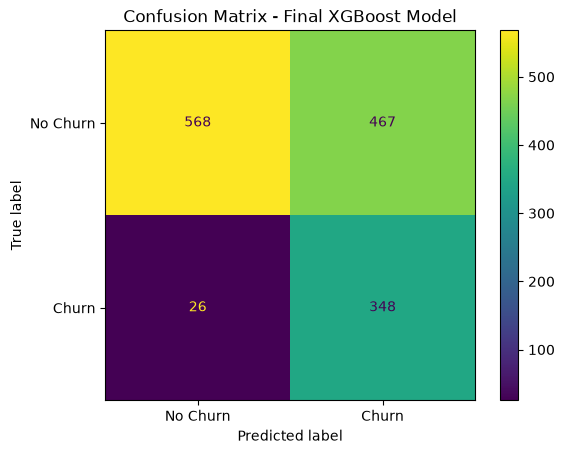

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_test_proba = best_xgb_optuna.predict_proba(X_test)[:, 1]

# Final threshold
y_test_pred = (y_test_proba >= 0.12).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Final XGBoost Model")
plt.show()

XGBoost with Optuna was selected as the final model because it achieved a strong balance between the primary objective of detecting churners and maintaining a reasonable precision. At a decision threshold of 0.12, the model achieved 93.05% recall, 42.70% precision, and 58.54% F1-score on the test set. Although Logistic Regression with class balancing achieved a slightly higher recall of 96.26%, its lower precision of 38.88% resulted in a less balanced performance.

# Model Saving & Serialization

In [ ]:
import joblib

final_model = {
    "model": best_xgb_optuna,
    "threshold": 0.12
}

joblib.dump(
    final_model,
    "models/final_xgboost_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [ ]:
import mlflow

import mlflow

mlflow.set_experiment("Telco-Customer-Churn")

2026/08/19 03:38:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/19 03:38:13 INFO mlflow.store.db.utils: Updating database tables
2026/08/19 03:38:14 INFO mlflow.tracking.fluent: Experiment with name 'Telco-Customer-Churn' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/NADA/Projects/Personal/AI/MachineLearning/Telco-Customer-Churn-ML/notebooks/.ipynb_checkpoints/mlruns/1', creation_time=1787103494419, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787103494419, lifecycle_stage='active', name='Telco-Customer-Churn', tags={}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run(run_name="XGBoost_Optuna_Final"):

    # Log the threshold
    mlflow.log_param("threshold", 0.12)

    # Log the metrics
    mlflow.log_metric("accuracy", 0.6501)
    mlflow.log_metric("precision", 0.4270)
    mlflow.log_metric("recall", 0.9305)
    mlflow.log_metric("f1_score", 0.5854)

    print("MLflow run recorded successfully.")

MLflow run recorded successfully.


In [ ]:
with mlflow.start_run(run_name="XGBoost_Optuna_Final"):

    # Log Optuna hyperparameters
    mlflow.log_params(study.best_params)

    # Log threshold
    mlflow.log_param("threshold", 0.12)

    # Log metrics
    mlflow.log_metric("accuracy", 0.6501)
    mlflow.log_metric("precision", 0.4270)
    mlflow.log_metric("recall", 0.9305)
    mlflow.log_metric("f1_score", 0.5854)

    print("Parameters and metrics logged.")

Parameters and metrics logged.


In [ ]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="XGBoost_Optuna_Final"):

    # Hyperparamètres trouvés par Optuna
    mlflow.log_params(study.best_params)

    # Threshold final
    mlflow.log_param("threshold", 0.12)

    # Métriques sur le TEST
    mlflow.log_metric("accuracy", 0.650106)
    mlflow.log_metric("precision", 0.426994)
    mlflow.log_metric("recall", 0.930481)
    mlflow.log_metric("f1_score", 0.585366)

    # Enregistrer le pipeline complet
    mlflow.sklearn.log_model(
        best_xgb_optuna,
        name="model",
        serialization_format="cloudpickle",
        registered_model_name="TelcoChurnXGBoost"
    )

print("Final run successfully logged!")

2026/08/19 03:50:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'TelcoChurnXGBoost'.
2026/08/19 03:50:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: TelcoChurnXGBoost, version 1


🏃 View run XGBoost_Optuna_Final at: http://127.0.0.1:5000/#/experiments/2/runs/bf32eed682784ceca7e069f05e5bef43
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Final run successfully logged!


Created version '1' of model 'TelcoChurnXGBoost'.


In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("Telco-Customer-Churn")

2026/08/19 03:48:50 INFO mlflow.tracking.fluent: Experiment with name 'Telco-Customer-Churn' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1787104130804, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1787104130804, lifecycle_stage='active', name='Telco-Customer-Churn', tags={}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run(run_name="Logistic_Balanced"):

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("threshold", 0.20)
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("accuracy", 0.5884)
    mlflow.log_metric("precision", 0.3888)
    mlflow.log_metric("recall", 0.9626)
    mlflow.log_metric("f1_score", 0.5538)

    mlflow.sklearn.log_model(
        logistic_balanced,
        name="model",
        serialization_format="cloudpickle"
    )

print("Logistic run recorded.")

2026/08/19 18:04:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic_Balanced at: http://127.0.0.1:5000/#/experiments/2/runs/1323d2bd593c4a0fbd7149e783858988
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Logistic run recorded.


In [ ]:
# ============================================================
# TEST : XGBoost + Optuna + OneHotEncoder(drop="if_binary")
# ============================================================

import mlflow
import mlflow.sklearn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. Définir les variables
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns


# ------------------------------------------------------------
# 2. Nouveau preprocessing
# ------------------------------------------------------------

preprocessor_drop_binary = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 3. XGBoost avec les meilleurs paramètres Optuna
# ------------------------------------------------------------

xgb_drop_binary = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss"
)


# ------------------------------------------------------------
# 4. Pipeline complet
# ------------------------------------------------------------

xgb_drop_binary_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_drop_binary),
        ("model", xgb_drop_binary)
    ]
)


# ------------------------------------------------------------
# 5. Entraînement
# ------------------------------------------------------------

xgb_drop_binary_pipeline.fit(X_train, y_train)


# ------------------------------------------------------------
# 6. Probabilités sur TEST
# ------------------------------------------------------------

y_test_proba_drop = (
    xgb_drop_binary_pipeline.predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 7. Tester plusieurs thresholds
# ------------------------------------------------------------

thresholds = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20]

results_drop = []

for threshold in thresholds:

    y_test_pred = (
        y_test_proba_drop >= threshold
    ).astype(int)

    results_drop.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred)
    })


# ------------------------------------------------------------
# 8. Afficher les résultats
# ------------------------------------------------------------

import pandas as pd

results_drop_df = pd.DataFrame(results_drop)

print("XGBoost + Optuna + drop='if_binary'")
print()

print(
    results_drop_df.to_string(
        index=False,
        formatters={
            "accuracy": "{:.4f}".format,
            "precision": "{:.4f}".format,
            "recall": "{:.4f}".format,
            "f1": "{:.4f}".format
        }
    )
)


# ------------------------------------------------------------
# 9. Trouver le meilleur threshold avec Recall >= 90%
#    et Precision la plus élevée
# ------------------------------------------------------------

candidates = results_drop_df[
    results_drop_df["recall"] >= 0.90
]

if len(candidates) > 0:

    best_candidate = candidates.loc[
        candidates["precision"].idxmax()
    ]

    print("\n" + "=" * 60)
    print("BEST CANDIDATE (Recall >= 90%)")
    print("=" * 60)

    print(
        f"Threshold : {best_candidate['threshold']:.2f}"
    )

    print(
        f"Accuracy  : {best_candidate['accuracy']:.4f}"
    )

    print(
        f"Precision : {best_candidate['precision']:.4f}"
    )

    print(
        f"Recall    : {best_candidate['recall']:.4f}"
    )

    print(
        f"F1        : {best_candidate['f1']:.4f}"
    )


    # --------------------------------------------------------
    # 10. Enregistrer le test dans MLflow
    # --------------------------------------------------------

    with mlflow.start_run(
        run_name="XGBoost_Optuna_DropBinary"
    ):

        mlflow.log_param(
            "model",
            "XGBoost + Optuna"
        )

        mlflow.log_param(
            "preprocessing",
            "OneHotEncoder(drop='if_binary')"
        )

        mlflow.log_param(
            "threshold",
            float(best_candidate["threshold"])
        )

        mlflow.log_params(study.best_params)

        mlflow.log_metric(
            "accuracy",
            float(best_candidate["accuracy"])
        )

        mlflow.log_metric(
            "precision",
            float(best_candidate["precision"])
        )

        mlflow.log_metric(
            "recall",
            float(best_candidate["recall"])
        )

        mlflow.log_metric(
            "f1_score",
            float(best_candidate["f1"])
        )

        mlflow.sklearn.log_model(
            xgb_drop_binary_pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print("\nMLflow run saved successfully.")

else:

    print(
        "\nAucun threshold n'a atteint Recall >= 90%."
    )

NameError: name 'X_train' is not defined

In [ ]:
import great_expectations as gx

context = gx.get_context(mode="file")

data_source = context.data_sources.add_pandas(name="pandas_source")

data_asset = data_source.add_dataframe_asset(name="telco_data")

batch_definition = data_asset.add_batch_definition_whole_dataframe(
    "telco_batch"
)

batch = batch_definition.get_batch(
    batch_parameters={"dataframe": df}
)

In [ ]:
expectation = gx.expectations.ExpectColumnValuesToNotBeNull(
    column="customerID"
)

result = batch.validate(expectation)

print(result)

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "batch_id": "pandas_source-telco_data",
      "column": "customerID"
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 7043,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": [],
    "partial_unexpected_counts": [],
    "partial_unexpected_index_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}
